<a href="https://colab.research.google.com/github/thatGirlintheCorner/PythonHashFunctions/blob/main/Assignment3_CryptographicHashFunctions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment #3: Cryptographic Hash Functions

Task 1: Exploring Pseudo-Randomness and Collision Resistance

a. We defined a function, hash() which takes in strings and hashes them using SHA256, then prints the digest in hexadecimal.

b. Defined two functions, ham_dist() and find_ham_dist_1(). The first takes in two strings and calculates the hamming distance between them. The second creates a random base string and modifies it to build another string with a hamming distance of 1 from the base.

c. For this portion of the task, we combined techniques from the previous portions to create random strings and saving them and their hashes to a dictionary. This was run until a collision was found, meaning two different input strings have the same hash. These collisions were found for hashes of bit even lengths from 8-50.

Task 1a: SHA256 hashes of arbitrary inputs
Input 1: Hello, World!
Hash 1: dffd6021bb2bd5b0af676290809ec3a53191dd81c7f70a4b28688a362182986f

Input 2: Python
Hash 2: 18885f27b5af9012df19e496460f9294d5ab76128824c6f993787004f6d9a7db

Input 3: Cryptography
Hash 3: b584eec728548aced5a66c0267dd520a00871b5e7b735b2d8202f86719f61857

Task 1b: Strings with Hamming Distance of 1
String 1: ycxoSWQAzb
String 2: xcxoSWQAzb
SHA256 (1): d3f2ae6d4fe8ed72fc0c5dfe842a73fc0423f81797aa4e5e3eaf218eeb7e202d
SHA256 (2): ed084bf77c23e6bfe2ccb56f9fd1e3691c90169e697234a5ae6ff05c46cad491

String 1: RdrDFRiUcc
String 2: SdrDFRiUcc
SHA256 (1): 9e56f7b0a6c8577f9b42fd87074fa8b27da2fe866ad6dfc4e859a92b46633235
SHA256 (2): faf1efa4e40f03283777e6400d0232afa2ac52c3c9b2758da4426fe3a873dd89

String 1: roTDcBmcLH
String 2: soTDcBmcLH
SHA256 (1): 4f27ee91e2068f87d642e767ad8cfce095b5490d5b174031e2fc2c23289ea54d
SHA256 (2): e0ed0dcf39ae0bb1ea1a428b418405cda17e069793977d1682cc844283d06149

Task 1c: Finding collisions for truncat

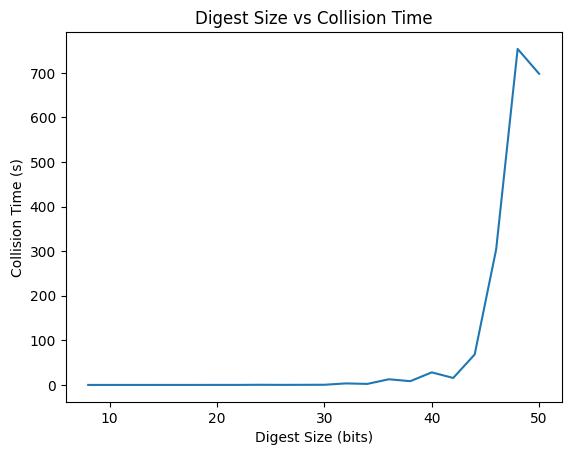

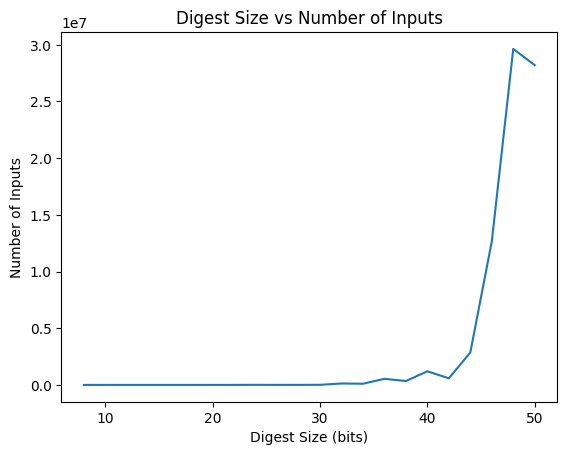

In [ ]:
from numpy import triu_indices
from IPython.core.shellapp import ENV_CONFIG_DIRS
import matplotlib.pyplot as plt
from prettytable import PrettyTable
from Crypto.Hash import SHA256

import string
import random
import time

def hash(input):
  input_bytes = input.encode("utf-8")
  h = SHA256.new()
  h.update(input_bytes)
  return h.hexdigest()

def ham_dist(str1, str2):
  count = 0
  for i in range(len(str1)):
    if str1[i] != str2[i]:
      count += 1
  return count

def find_ham_dist_1():
# generate base of 10 ascii letters
  base = ""
  for i in range(10):
    base += random.choice(string.ascii_letters)
  base_bytes = bytearray(base, "utf-8")
  for i in range(len(base_bytes)):
    # flip ith bit
    modified = int.from_bytes(base_bytes, "little")
    mask = 1 << i
    if modified & mask:
      modified = modified - mask
    else:
      modified = modified + mask
    modified_str = (modified.to_bytes(len(base_bytes), "little")).decode("utf-8")
    if ham_dist(base, modified_str) == 1:
      return (base, modified_str)
  return (None, None)

def truncate_hash(hash_string, bits):
  # Take the first (bits / 4) characters of hash_string
  substr = hash_string[:(bits//4)]
  # Convert this substring to an integer (base 16)
  substr_bytes = substr.encode("utf-8")
  # Create a bitmask of 'bits' number of 1s
  mask = (1 << bits) - 1
  # Perform bitwise AND between the integer and the bitmask
  # Return the result
  return hex( mask & int(substr_bytes, 16))

def find_colls(bits):
  seen = {}
  # record start time
  start = time.perf_counter()
  attempts = 0
  while True:
    attempts += 1
    s = ""
    for i in range(10):
      s += random.choice(string.ascii_letters)
    # calc truncated hash h for s
    h = truncate_hash(hash(s), bits)
    if h in seen:
      # calc end time
      end = time.perf_counter()
      print(f"{seen[h]}, {s}, {h}, {attempts}, {(end - start)}")
      return seen[h], s, h, attempts, (end - start)
    else:
      # add s to seen with key h
      seen[h] = s

def task_1a():
  print("Task 1a: SHA256 hashes of arbitrary inputs")
  inputs = ["Hello, World!", "Python", "Cryptography"]
  for i in range(len(inputs)):
    h = hash(inputs[i])
    print(f"Input {i+1}: {inputs[i]}")
    print(f"Hash {i+1}: {h}\n")

def task_1b():
  print("Task 1b: Strings with Hamming Distance of 1")
  for i in range(3):
    (str1, str2) = find_ham_dist_1()
    h1 = hash(str1)
    h2 = hash(str2)
    print(f"String 1: {str1}")
    print(f"String 2: {str2}")
    print(f"SHA256 (1): {h1}")
    print(f"SHA256 (2): {h2}\n")

def task_1c():
  print("Task 1c: Finding collisions for truncated hashes")
  bits = []
  times = []
  inputs = []
  hashes = []
  tries = []
  for b in range(8, 51, 2):
    (in1, in2, h, attempts, time) = find_colls(b)
    inputs.append(in1)
    inputs.append(in2)
    hashes.append(h)
    tries.append(attempts)
    times.append(time)
    bits.append(b)
  # Print results table
  t = PrettyTable(['Bits', 'Input 1', 'Input 2', 'Hash', 'Inputs Tried', 'Time (s)'])
  print("Results:")
  t = PrettyTable(['Bits', 'Input 1', 'Input 2', 'Hash', 'Inputs Tried', 'Time (s)'])
  for i in range(len(bits)):
    t.add_row([bits[i], inputs[i*2], inputs[(i*2)+1], hashes[i], tries[i], times[i]])
  print(t)
  # Print and save graphs
  plt.title("Digest Size vs Collision Time")
  plt.plot(bits, times)
  plt.ylabel('Collision Time (s)')
  plt.xlabel('Digest Size (bits)')
  plt.savefig("collision_analysis1.png")
  plt.show()
  plt.title("Digest Size vs Number of Inputs")
  plt.plot(bits, tries)
  plt.ylabel('Number of Inputs')
  plt.xlabel('Digest Size (bits)')
  plt.savefig("collision_analysis2.png")
  plt.show()

def main():
  task_1a()
  task_1b()
  task_1c()

if __name__ == "__main__":
  main()


Task 2: Breaking Real Hashes
Our implementation comes in two parts, first is to parse the line of text we are given, and then testing that against the hash. Our second part is multitreading the solution, to ensure that we get everything done in a reasonable time frame.

First, parsing the text is trivial, and hashing it just requires us to use bcrypt's function to check the password. It checks the word we're trying to use by hashing it, using the infomration given in the data like the salt, then it checks against the hash in the line. If they match, then the password is a hit, and we want to record it. Otherwise, just keep checking words.

Second, our multithreading solution here just creates a new thread for each of the 15 lines of text that we want to crack, so that they all run in parallel. There's better implementaions for this, as roughly illustrated by the comment above the main function, but it does the trick for a one time usecase like this.

In [ ]:
import time
import bcrypt
import threading
from nltk.corpus import words

# getting the word list from nltk
word_list = word_list = words.words()
word_list_len = len(word_list)

def crack_password(line_index):
    # start timer
    start_time = time.time()

    # read in our specific line
    password_list = open("./passwords.txt").read()
    password_line = password_list.split('\n')[line_index]
    print(password_line)
    parsed_password = password_line.split('$')
    user_name = parsed_password[0][:-1]
    algorithm = parsed_password[1]
    workfactor = parsed_password[2]
    salt_str = parsed_password[3]

    # getting just the salt for the bcrypt
    bcrypt_salt = f"${algorithm}${workfactor}${salt_str}"
    bcrypt_salt = bcrypt_salt.encode()

    # start the serach for our word
    word_index = 0
    cracked_password = "<Not found>"
    while word_index < word_list_len:
        word = word_list[word_index]
        if len(word) >= 6 and len(word) <= 10:
            # if our word hashes to the same value as in the bcrypt_salt
            #    (which isn't reallly just the salt, it includes most of the line),
            # then it returns true, letting us assign the word, and stop the thread
            if bcrypt.checkpw(word.encode(), bcrypt_salt):
                cracked_password = word
                break
        word_index += 1

    # gives a simple, livie output to let us check in on
    output_text = user_name + ' ' + cracked_password + ' ' + str(round(time.time()-start_time, 2)) + ' seconds'
    print(output_text)

    # the actual file output, one file for each user
    output_file = open("./cracked_passwords/" + user_name + ".txt", 'w')
    output_file.write(output_text)


# NOTE: the main code is sloppy, but it works fine for this case. a list of threads would have been better.
# here's an example of the control flow of a shortened main function
# thread_list = []
# for i in range(15):
#   thread_list.append(threading.Thread(target=crack_password, args=(i,)))
#   thread_list[i].start(); thread_list[i].join()

if __name__ == "__main__":
    # creating a process for each line
    thread0 = threading.Thread(target=crack_password, args=(0,))
    thread1 = threading.Thread(target=crack_password, args=(1,))
    thread2 = threading.Thread(target=crack_password, args=(2,))
    thread3 = threading.Thread(target=crack_password, args=(3,))
    thread4 = threading.Thread(target=crack_password, args=(4,))
    thread5 = threading.Thread(target=crack_password, args=(5,))
    thread6 = threading.Thread(target=crack_password, args=(6,))
    thread7 = threading.Thread(target=crack_password, args=(7,))
    thread8 = threading.Thread(target=crack_password, args=(8,))
    thread9 = threading.Thread(target=crack_password, args=(9,))
    thread10 = threading.Thread(target=crack_password, args=(10,))
    thread11 = threading.Thread(target=crack_password, args=(11,))
    thread12 = threading.Thread(target=crack_password, args=(12,))
    thread13 = threading.Thread(target=crack_password, args=(13,))
    thread14 = threading.Thread(target=crack_password, args=(14,))

    # start every thread
    thread0.start()
    thread1.start()
    thread2.start()
    thread3.start()
    thread4.start()
    thread5.start()
    thread6.start()
    thread7.start()
    thread8.start()
    thread9.start()
    thread10.start()
    thread11.start()
    thread12.start()
    thread13.start()
    thread14.start()

    # let each thread finish before terminating the program
    thread0.join()
    thread1.join()
    thread2.join()
    thread3.join()
    thread4.join()
    thread5.join()
    thread6.join()
    thread7.join()
    thread8.join()
    thread9.join()
    thread10.join()
    thread11.join()
    thread12.join()
    thread13.join()
    thread14.join()

The program returned 15 files, which after compiling into one single txt, we then exported into a spreadsheet to create the following image. Our shortest crack was 7 minutes, and our longest was 11.5 hours.

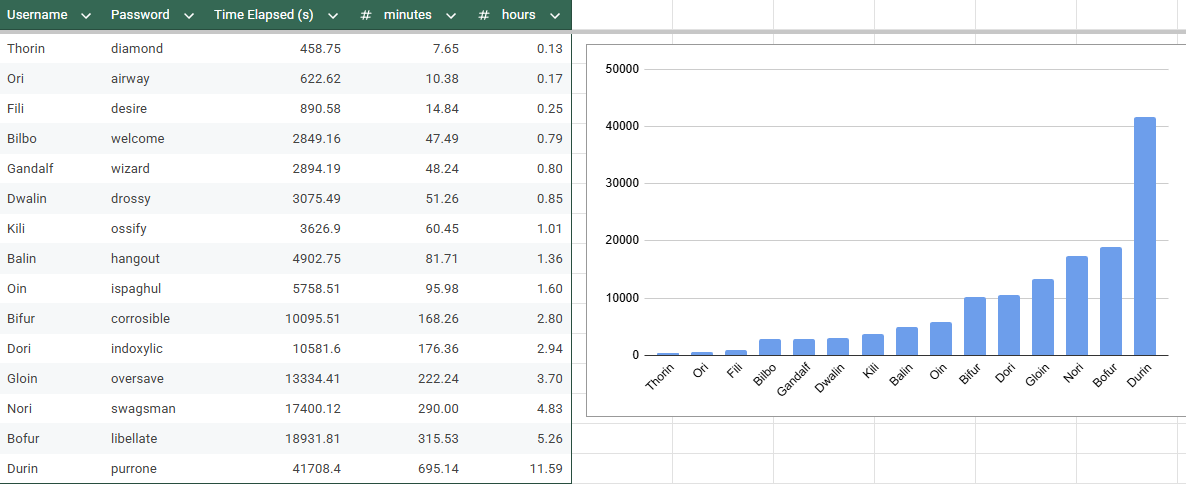

Questions:

1. What do you observe based on Task 1b? How many bytes are different
between the two digests?

For this task, although the hashes are radically different from each other, the strings which have a hamming distance of one are almost exactly the same. In all the cases, only one byte is different between the two strings, meaning they have all but one of the same characters.

2. What is the maximum number of files you would ever need to hash to find a
collision on an n-bit digest? Given the birthday bound, what is the expected
number of hashes before a collision on an n-bit digest? Is this what you
observed? Based on the data you have collected, speculate on how long it
might take to find a collision on the full 256-bit digest.

For a truely random hash with an n-bit digest, you would suspect 2^n files to be the maximum number needed to find a collision. However, due to the birthday bound, you actually only need a maximum of 2^(n/2) number of files for an n-bit digest. For our results of finding collisions for hashes of 8 to 50 bits, this boundary did hold true. Based on this, a full 256-bit digest would theoretically take 2^(265/2) files which is 2^128. This is equal to about 10^38 tries. For modern computers, this would take a staggering amount of time and I don't believe it would even be possible with our current computational power.

3. Given an 8-bit digest, would you be able to break the one-way property (i.e.
can you find any pre-image)? Do you think this would be easier or harder than
finding a collision? Why or why not?

For a small hash like an 8-bit digest, it would be possible to break the one-way property and find a pre-image. Through brute force, the pre-image attack has a complexity of 2^n for n-bits. For modern computers, 2^8 is not a significant barrier. However, it is still harder than finding a collision. Due to the statistical significances outlined in the Birthday problem, the complexity of finding a collision is only 2^(n/2), which is significantly lower, especially considering a small input size of an 8-bit digest.

4. For Task 2, given your results, how long would it take to brute force a
password that uses the format word1:word2 where both words are between 6
and 10 characters? What about word1:word2:word3? What about
word1:word2:number where number is between 1 and 5 digits? Make sure to sufficiently justify your answers.

With our current solution, we can assume that it takes O(n) time to find a password (a very slow O(1) hash, and checking against a list of n words). With that information, we know that for a password like word1:word2, it would have to check every word against every other word in the dataset, therefore squaring the possible combinations. This would lead our time complexity to O(n^2). The same logic can apply to the three word case, getting O(n^3). In the case with the added number, it would roughly follow a O(10^4 * n^2) solution, which while the leading value typically gets absored in an estimate like this, it's significant enough to state that it would add a drastic amount of time, as it's a similar value to n in this case [the number of words in the nltk set, without removing smaller and larger words than 6 and 10 characters respectively, was a little less than a quarter million words, or 2.3*10^5].